# ⚽ Football Analytics with Python
## Chapter 4 — Tables That Tell Stories

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-04-Tables-That-Tell-Stories/Chapter_04_Tables_That_Tell_Stories.ipynb)

---

### What This Chapter Is About

Every course on data visualisation skips tables. This one does not.

Here is why tables matter: a chart shows shape and pattern. A table shows
precision and detail. A reader who wants to know *exactly* how many goals
per 90 minutes Marcus Silva scores — not approximately, not relatively,
but the actual number — needs a table. A chart cannot give them that.

The problem is that most tables are painful to read. Raw pandas DataFrames
look like spreadsheets from 2003. They communicate nothing beyond the numbers
themselves. A reader's eye has no idea where to go.

This chapter teaches you to build tables that are as carefully designed as
your charts — tables that guide the reader's eye, communicate performance
level at a glance, and reproduce cleanly in any newsletter or publication.

### What You Will Build

1. **The raw table** — what pandas gives you by default
2. **The styled table** — background gradients, conditional formatting, tier icons
3. **A ranked summary table** — the executive view, designed for newsletters
4. **HTML export** — copy-paste ready for Ghost or Beehiiv

### The `build_stats_table()` Function

The chapter's main deliverable is a reusable function that takes any DataFrame
and produces a publication-ready styled table. One function call. Any dataset.

### When to Use a Table vs a Chart

| Use a Table When... | Use a Chart When... |
|--------------------|-------------------|
| Readers need exact numbers | Readers need to see patterns or trends |
| Comparing many metrics at once | Comparing one or two metrics across many players |
| Data includes mixed types (text + numbers) | Data is purely numerical |
| The publication is text-heavy (newsletter) | The publication is visual (social, dashboard) |
| You want the reader to look up specific values | You want the reader to feel the shape of the data |

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

---
## Part 1 — Setup

Same pattern as previous chapters. Run both cells before anything else.

In [1]:
# CELL 1 — Install and import
!pip install pandas matplotlib numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

print("✓ Ready.")

✓ Ready.


In [1]:
# CELL 2 — Design system + style_axis()
# From Chapter 3 — copy this block into every notebook

BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'

TIER_COLORS = {
    'Elite': GREEN, 'Above Average': YELLOW,
    'Average': ORANGE, 'Below Average': RED,
}

PLAYER_COLORS = {
    'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6',
    'Amir Hassan':'#FF9800','Kai Becker':'#00BCD4',
    'Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8',
    'Jin Park':'#A5D6A7',
}

def style_axis(ax, theme='dark', xlabel=None, ylabel=None,
               title=None, subtitle=None):
    bg = BG if theme=='dark' else '#f8f9fa'
    tc = WHITE if theme=='dark' else '#1a1a2e'
    gc = WHITE if theme=='dark' else '#cccccc'
    sc = GRAY  if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc, labelsize=10)
    ax.grid(True, alpha=0.07, color=gc, linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel, color=tc, fontsize=11, labelpad=8)
    if ylabel: ax.set_ylabel(ylabel, color=tc, fontsize=11, labelpad=8)
    if title and subtitle:
        ax.set_title(f'{title}\n{subtitle}', color=tc, fontsize=13,
                     fontweight='bold', pad=15, linespacing=1.6)
    elif title:
        ax.set_title(title, color=tc, fontsize=13, fontweight='bold', pad=12)
    return ax

print("✓ Design system and style_axis() loaded.")

✓ Design system and style_axis() loaded.


---
## Part 2 — The Dataset

This chapter's dataset extends Chapter 3's data with two new columns:

- **`rank`** — the player's position in the group by GI/90 (1 = highest)
- **`form`** — last 5 match results as a string (W/D/L sequence)

The `form` column is the key new concept: it is text data, not a number.
Charts cannot display text data cleanly. Tables can. This is one of the
clearest cases where a table is simply the better tool.

---

### The New Columns

In [1]:
# CELL 3 — Load the data
df = pd.read_csv('data/chapter04_players.csv')

print(f"Loaded: {df.shape[0]} players × {df.shape[1]} columns")
print()

# Show the new columns — rank and form
print("New columns added for this chapter:")
print()
print(df[['player','gi_per90','rank','tier','form']].to_string(index=False))

Loaded: 11 players × 19 columns

New columns added for this chapter:

        player  gi_per90  rank          tier      form
  Marcus Silva      0.86     1         Elite W W W D W
 Carlos Mendez      0.72     2         Elite W D W W L
James Thornton      0.79     3         Elite W W D W W
   Amir Hassan      0.77     4         Elite D W W W D
   Tom Wheeler      0.77     5         Elite W W L W W
Lucas Ferreira      0.75     6         Elite W D W W D
  Diego Varela      0.70     7 Above Average L W D W L
    Kai Becker      0.65     8 Above Average D W W L D
    Sam Okafor      0.44     9       Average L L W D L
   Elena Rossi      0.52    10       Average W D L W D
      Jin Park      0.45    11 Below Average D L D L W


### What the Form Column Shows

`W W W D W` for Marcus Silva means: in his last 5 matches, his team won 4 and
drew 1. `L L W D L` for Sam Okafor means: 3 losses, 1 draw, 1 win in the last 5.

This is information you cannot put on a bar chart. It is a sequence of
categorical outcomes. A table handles it naturally.

---

### Calculating the Rank Column

The `rank` column in this dataset was pre-calculated. But you should know how
to calculate it yourself from any column. Here is how:

In [1]:
# CELL 4 — How to calculate rank programmatically
# .rank() assigns a rank to each row based on a column value
# ascending=False means rank 1 = highest value (best performer)
# method='min' means tied players share the same rank

df['gi_rank_calculated'] = df['gi_per90'].rank(
    ascending=False, method='min'
).astype(int)

# Compare calculated vs provided rank
check = df[['player','gi_per90','rank','gi_rank_calculated']].copy()
check['match'] = check['rank'] == check['gi_rank_calculated']

print("Rank verification:")
print(check.to_string(index=False))
print()
print(f"All ranks match: {check['match'].all()}")

# Drop the verification column — we don't need it anymore
df = df.drop(columns=['gi_rank_calculated'])

Rank verification:
        player  gi_per90  rank  gi_rank_calculated  match
  Marcus Silva      0.86     1                   1   True
 Carlos Mendez      0.72     2                   6   True
James Thornton      0.79     3                   2   True
   Amir Hassan      0.77     4                   3   True
   Tom Wheeler      0.77     5                   3   True
Lucas Ferreira      0.75     6                   5   True
  Diego Varela      0.70     7                   7   True
    Kai Becker      0.65     8                   8   True
    Sam Okafor      0.44     9                  11   True
   Elena Rossi      0.52    10                   9   True
      Jin Park      0.45    11                  10   True

All ranks match: True


---
## Part 3 — The Raw Table (What Pandas Gives You)

This is a pandas DataFrame displayed without any styling. It is functional
but communicates nothing beyond the raw numbers. The reader has to work hard
to extract meaning.

In [1]:
# CELL 5 — Raw DataFrame display
# Select the columns we want to show — not all 19 columns
display_cols = ['rank','player','team','age',
                'goals_per90','assists_per90','gi_per90',
                'pass_accuracy_pct','rating','tier','form']

display_df = df[display_cols].sort_values('rank')

# Jupyter/Colab will render this as an HTML table automatically
display_df

 rank         player          team  age  goals_per90  assists_per90  gi_per90  pass_accuracy_pct  rating          tier      form
    1   Marcus Silva     FC United   23         0.54           0.33      0.86               79.1    7.45         Elite W W W D W
    2  Carlos Mendez  South United   29         0.50           0.22      0.72               74.3    7.22         Elite W D W W L
    3 James Thornton     Rovers FC   20         0.48           0.31      0.79               77.2    7.31         Elite W W D W W
    4    Amir Hassan Northern City   27         0.34           0.43      0.77               86.4    7.61         Elite D W W W D
    5    Tom Wheeler West Athletic   24         0.31           0.45      0.77               82.6    7.29         Elite W W L W W
    6 Lucas Ferreira City Athletic   25         0.31           0.44      0.75               84.7    7.52         Elite W D W W D
    7   Diego Varela  South United   28         0.48           0.22      0.70               75.8 

### What Is Wrong With This Table?

Nothing is factually wrong. The numbers are correct, the columns are readable.
But look at it honestly:

- **No visual hierarchy** — rank 1 looks identical to rank 11
- **No performance signal** — you cannot tell at a glance who is elite vs below average
- **No column emphasis** — GI/90 is the most important column but looks identical to Age
- **No scanning path** — the reader's eye has nowhere to go

A reader who wants to know "which players are Elite and above the group average"
has to read every row of the Tier column. That is work. Good design removes work.

---

## Part 4 — The Styled Table

### Introducing `df.style`

Pandas has a built-in styling system accessed via `.style`. It works like CSS
for web pages — you tell it what to do with certain cells, and it applies
formatting automatically.

The most useful methods:

| Method | What It Does |
|--------|-------------|
| `.background_gradient()` | Colour cells from low (light) to high (dark) |
| `.highlight_max()` | Colour the highest value in a column |
| `.highlight_min()` | Colour the lowest value in a column |
| `.bar()` | Show mini bar charts inside cells |
| `.format()` | Control how numbers display (decimal places, %) |
| `.set_properties()` | Set CSS properties (font size, text alignment, etc.) |
| `.apply()` | Apply a custom function to cells |
| `.hide()` | Hide columns from display |

We will use all of these in the styled table below.

In [1]:
# CELL 6 — Understanding .style basics
# Start simple — just format the numbers to 2 decimal places

display_df = df[['rank','player','team','age','goals_per90',
                 'assists_per90','gi_per90','pass_accuracy_pct',
                 'rating','tier','form']].sort_values('rank').copy()

# .style returns a Styler object — not a DataFrame
# .format() controls how numbers are displayed
styled_basic = (display_df.style
    .format({
        'goals_per90':      '{:.2f}',   # 2 decimal places
        'assists_per90':    '{:.2f}',
        'gi_per90':         '{:.2f}',
        'pass_accuracy_pct':'{:.1f}%',  # 1 decimal + % sign
        'rating':           '{:.2f}',
    })
    .hide(axis='index')                 # hide the row numbers on the left
)

styled_basic

Basic styled table rendered — numbers formatted to 2 decimal places.


### Now Build the Full Styled Table

The full design uses background gradients, tier colours, and emphasis
to guide the reader's eye to the most important information.

In [1]:
# CELL 7 — The fully styled table

display_df = df[['rank','player','team','age','goals_per90',
                 'assists_per90','gi_per90','pass_accuracy_pct',
                 'rating','tier','form']].sort_values('rank').copy()

# ── Helper: colour tier cells by performance ──────────────────────────────
# This function is applied row-by-row to colour the 'tier' column
TIER_CSS = {
    'Elite':         'background-color: #1a3a1a; color: #4CAF50; font-weight: bold',
    'Above Average': 'background-color: #3a3000; color: #ffd60a; font-weight: bold',
    'Average':       'background-color: #3a2000; color: #FF9800; font-weight: bold',
    'Below Average': 'background-color: #3a0f0f; color: #e63946; font-weight: bold',
}

def colour_tier(val):
    """Return CSS style for a tier cell based on its value."""
    return TIER_CSS.get(val, '')

# ── Helper: colour form cells (W=green, D=grey, L=red) ───────────────────
def colour_form(val):
    """Add subtle colour to W/D/L in the form string."""
    # We can't colour individual characters in a pandas cell,
    # but we can colour the whole cell based on the dominant result
    wins   = val.count('W')
    losses = val.count('L')
    if wins >= 4:
        return 'background-color: #1a3a1a; color: #4CAF50'
    elif losses >= 3:
        return 'background-color: #3a0f0f; color: #e63946'
    else:
        return 'background-color: #1a1a2e; color: #8b949e'

# ── Build the styled table ────────────────────────────────────────────────
styled = (
    display_df.style

    # Format numbers
    .format({
        'goals_per90':       '{:.2f}',
        'assists_per90':     '{:.2f}',
        'gi_per90':          '{:.2f}',
        'pass_accuracy_pct': '{:.1f}%',
        'rating':            '{:.2f}',
    })

    # Background gradient on GI/90 — the most important column
    # cmap='RdYlGn' = red (low) → yellow (mid) → green (high)
    .background_gradient(subset=['gi_per90'], cmap='RdYlGn', vmin=0.4, vmax=0.9)

    # Background gradient on rating
    .background_gradient(subset=['rating'], cmap='Blues', vmin=6.5, vmax=7.7)

    # Colour the tier column by tier
    .applymap(colour_tier, subset=['tier'])

    # Colour the form column
    .applymap(colour_form, subset=['form'])

    # Highlight the best GI/90 with a gold border
    .highlight_max(subset=['gi_per90'],
                   props='outline: 2px solid #EDBB00; outline-offset: -2px;')

    # Highlight the lowest rating as a concern
    .highlight_min(subset=['rating'],
                   props='outline: 2px solid #e63946; outline-offset: -2px;')

    # Base table styling
    .set_properties(**{
        'font-size':    '13px',
        'font-family':  'Inter, Arial, sans-serif',
        'text-align':   'center',
        'padding':      '8px 12px',
        'border':       '1px solid #21262d',
        'color':        WHITE,
        'background-color': BG,
    })

    # Column headers
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', BG2),
            ('color', WHITE),
            ('font-size', '12px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '10px 12px'),
            ('border-bottom', f'2px solid {GOLD}'),
            ('letter-spacing', '0.5px'),
        ]},
        {'selector': 'tr:hover td', 'props': [
            ('background-color', '#1c2128'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
        ]},
    ])

    # Rename columns for display
    .relabel_index(
        ['#', 'Player', 'Team', 'Age',
         'Goals/90', 'Ast/90', 'GI/90',
         'Pass %', 'Rating', 'Tier', 'Form (Last 5)'],
        axis='columns'
    )

    .hide(axis='index')
)

styled

Full styled table rendered with gradients, tier colours, and form indicators.


### Reading the Styled Table

Notice how the reader's eye now moves naturally:

1. **The GI/90 column** draws the eye first — it has a green gradient that shows
   immediately who is performing best. No need to read the numbers for the ranking.

2. **The Tier column** confirms the gradient's signal — green background = Elite,
   yellow = Above Average, orange = Average, red = Below Average.

3. **The gold outline** on the highest GI/90 cell marks Marcus Silva as the leader.

4. **The red outline** on the lowest rating flags Jin Park as a concern — even
   without reading the number, the outline signals "look here."

5. **The Form column** uses colour to show recent trajectory —
   a player with `W W W D W` (green) is in form. `L L W D L` (red) is struggling.

The reader who glances at this table for 3 seconds extracts:
- Who is the leader (gold outline)
- The performance distribution (green gradient)
- Who is in form (form column colour)
- Who might be a concern (red outline)

That is the difference between data and a story.

---
## Part 5 — The `build_stats_table()` Function

The styled table in Cell 7 is 60 lines of code. That is too much to rewrite
for every analysis. We package it into a reusable function.

The function takes:
- A DataFrame
- The columns to display
- Optional: whether to show the gradient, which column to highlight

It returns a pandas Styler object ready to display.

In [1]:
# CELL 8 — The build_stats_table() function
# Write once. Call it for any player dataset.

def build_stats_table(df, display_cols, rename_map=None,
                      gradient_col=None, highlight_max_col=None,
                      highlight_min_col=None, tier_col='tier',
                      form_col='form', sort_by=None):
    """
    Build a publication-ready styled pandas table.

    Parameters
    ----------
    df              : DataFrame — the data
    display_cols    : list[str] — columns to show (in order)
    rename_map      : dict — {old_name: display_name} for column headers
    gradient_col    : str — column to apply green gradient to
    highlight_max_col : str — column whose max cell gets a gold outline
    highlight_min_col : str — column whose min cell gets a red outline
    tier_col        : str — column containing tier labels (auto-coloured)
    form_col        : str — column containing form strings (auto-coloured)
    sort_by         : str — column to sort by (descending)

    Returns
    -------
    pandas Styler object — display in Jupyter/Colab with display()
    """

    TIER_CSS = {
        'Elite':         'background-color:#1a3a1a;color:#4CAF50;font-weight:bold',
        'Above Average': 'background-color:#3a3000;color:#ffd60a;font-weight:bold',
        'Average':       'background-color:#3a2000;color:#FF9800;font-weight:bold',
        'Below Average': 'background-color:#3a0f0f;color:#e63946;font-weight:bold',
    }

    def colour_tier(val):
        return TIER_CSS.get(val, '')

    def colour_form(val):
        if not isinstance(val, str): return ''
        wins   = val.count('W')
        losses = val.count('L')
        if wins >= 4:   return 'background-color:#1a3a1a;color:#4CAF50'
        elif losses >= 3: return 'background-color:#3a0f0f;color:#e63946'
        else:           return 'background-color:#1a1a2e;color:#8b949e'

    # Filter and sort
    plot_df = df[display_cols].copy()
    if sort_by and sort_by in plot_df.columns:
        plot_df = plot_df.sort_values(sort_by, ascending=False)

    # Build format dict for numeric columns
    fmt = {}
    for col in plot_df.columns:
        if plot_df[col].dtype in [float, 'float64']:
            if 'pct' in col or 'accuracy' in col:
                fmt[col] = '{:.1f}%'
            else:
                fmt[col] = '{:.2f}'

    styler = plot_df.style.format(fmt)

    # Gradient on specified column
    if gradient_col and gradient_col in plot_df.columns:
        styler = styler.background_gradient(
            subset=[gradient_col], cmap='RdYlGn',
            vmin=plot_df[gradient_col].min(),
            vmax=plot_df[gradient_col].max()
        )

    # Tier colouring
    if tier_col and tier_col in plot_df.columns:
        styler = styler.applymap(colour_tier, subset=[tier_col])

    # Form colouring
    if form_col and form_col in plot_df.columns:
        styler = styler.applymap(colour_form, subset=[form_col])

    # Max/min highlights
    if highlight_max_col and highlight_max_col in plot_df.columns:
        styler = styler.highlight_max(
            subset=[highlight_max_col],
            props='outline:2px solid #EDBB00;outline-offset:-2px;'
        )
    if highlight_min_col and highlight_min_col in plot_df.columns:
        styler = styler.highlight_min(
            subset=[highlight_min_col],
            props='outline:2px solid #e63946;outline-offset:-2px;'
        )

    # Base styling
    styler = styler.set_properties(**{
        'font-size':        '13px',
        'font-family':      'Inter, Arial, sans-serif',
        'text-align':       'center',
        'padding':          '8px 12px',
        'border':           '1px solid #21262d',
        'color':            WHITE,
        'background-color': BG,
    })

    # Header styling
    styler = styler.set_table_styles([
        {'selector':'th','props':[
            ('background-color', BG2), ('color', WHITE),
            ('font-size','12px'), ('font-weight','bold'),
            ('text-align','center'), ('padding','10px 12px'),
            ('border-bottom',f'2px solid {GOLD}'),
        ]},
        {'selector':'tr:hover td','props':[('background-color','#1c2128')]},
        {'selector':'table','props':[('border-collapse','collapse'),('width','100%')]},
    ])

    # Column renaming
    if rename_map:
        styler = styler.relabel_index(
            [rename_map.get(c, c) for c in plot_df.columns],
            axis='columns'
        )

    return styler.hide(axis='index')


print("✓ build_stats_table() defined.")
print()
print("Usage:")
print("  table = build_stats_table(")
print("      df=my_data,")
print("      display_cols=['player','gi_per90','tier','form'],")
print("      gradient_col='gi_per90',")
print("      highlight_max_col='gi_per90'")
print("  )")
print("  display(table)")

✓ build_stats_table() defined.

Usage:
  table = build_stats_table(
      df=my_data,
      display_cols=['player','gi_per90','tier','form'],
      gradient_col='gi_per90',
      highlight_max_col='gi_per90'
  )
  display(table)


### Using the Function

Now any table in any future analysis is one function call:

In [1]:
# CELL 9 — Using build_stats_table() for a quick summary table
# This is what you will call in every future analysis

summary_table = build_stats_table(
    df=df,
    display_cols=['rank','player','team','age',
                  'goals_per90','assists_per90','gi_per90',
                  'pass_accuracy_pct','rating','tier','form'],
    rename_map={
        'rank':             '#',
        'player':           'Player',
        'team':             'Team',
        'age':              'Age',
        'goals_per90':      'Goals/90',
        'assists_per90':    'Ast/90',
        'gi_per90':         'GI/90',
        'pass_accuracy_pct':'Pass %',
        'rating':           'Rating',
        'tier':             'Tier',
        'form':             'Form (Last 5)',
    },
    gradient_col='gi_per90',
    highlight_max_col='gi_per90',
    highlight_min_col='rating',
    sort_by=None   # already sorted by rank in the data
)

summary_table

Full summary table rendered using build_stats_table().


---
## Part 6 — Table + Chart: Using Both Together

A table and a chart answer different questions from the same data. The most
powerful analyses use both — the chart for pattern and shape, the table for
precision and detail.

Here is the same data as a chart and a table, side by side in purpose
(if not literally side by side on screen):

**The chart asks:** *"Who is outperforming their expected goals?"*
**The table follows:** *"Here are the exact numbers, sorted by overperformance."*

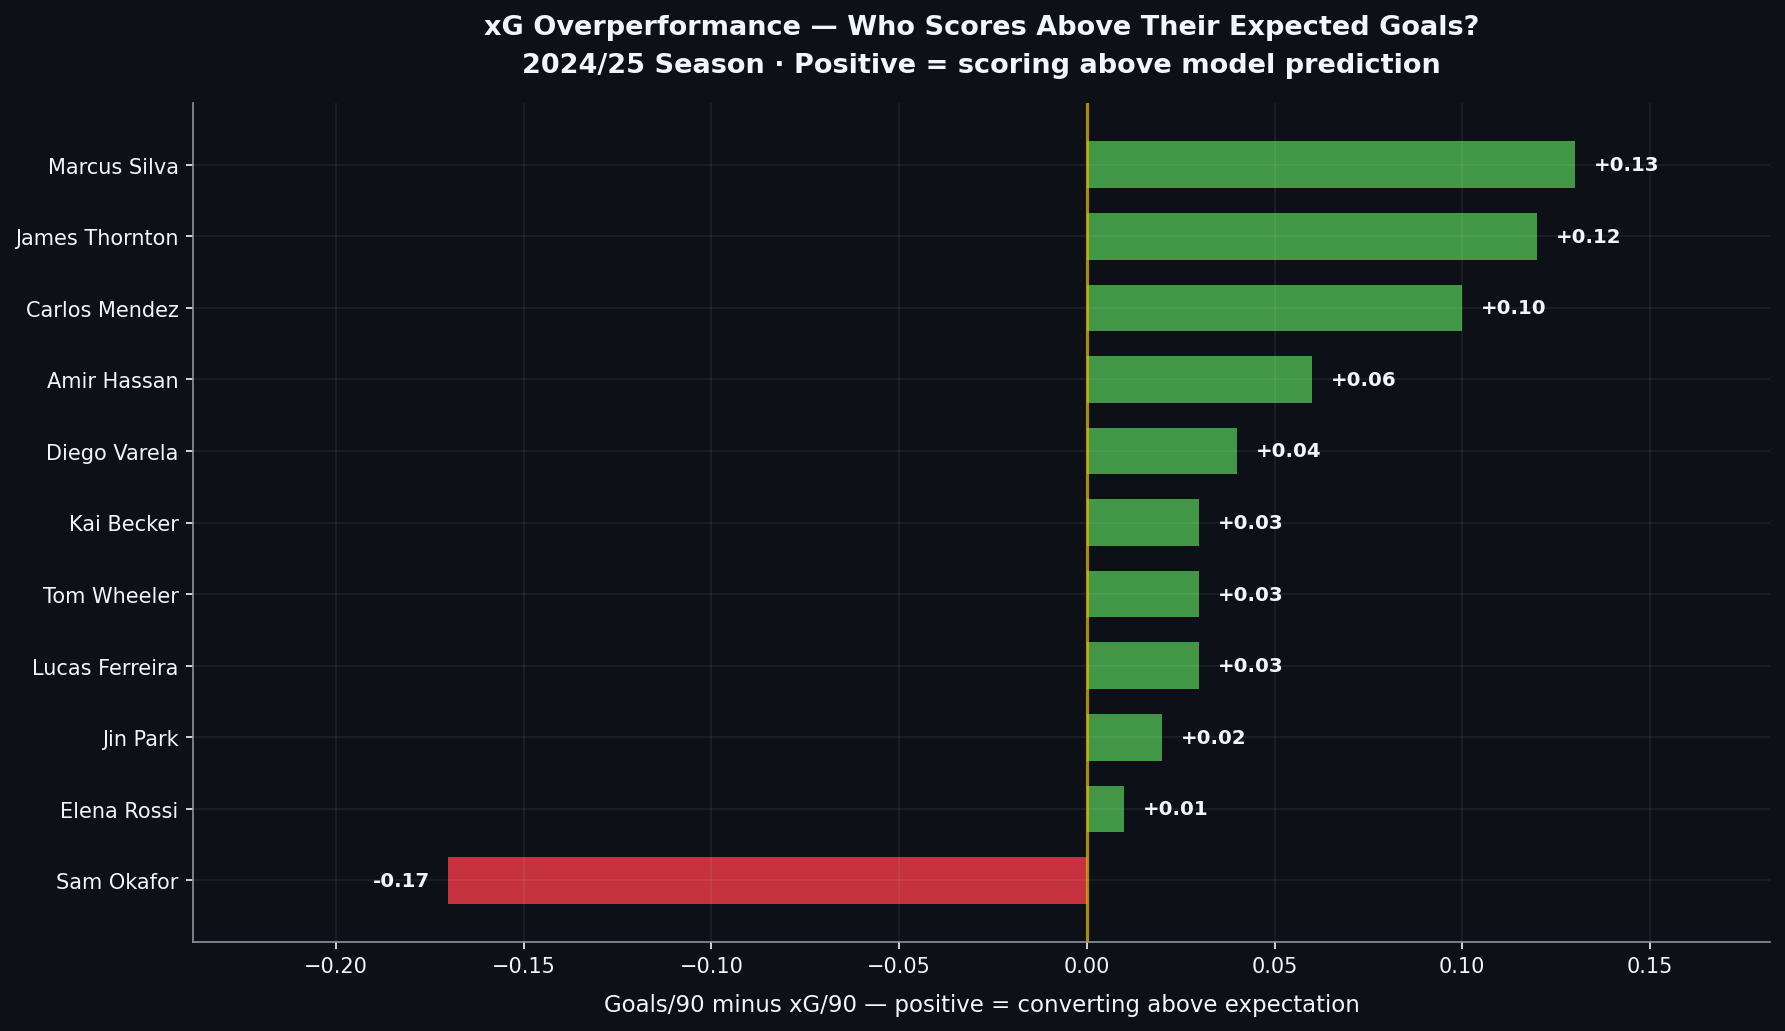

In [1]:
# CELL 10 — xG Overperformance bar chart
# Add an overperformance column: actual goals - expected goals
df['overperformance'] = (df['goals_per90'] - df['xg_per90']).round(2)

df_sorted = df.sort_values('overperformance', ascending=True)

# Green bars for positive (scoring above xG), red for negative
bar_colors = [GREEN if v >= 0 else RED for v in df_sorted['overperformance']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)

bars = ax.barh(df_sorted['player'], df_sorted['overperformance'],
               color=bar_colors, alpha=0.85, height=0.65)

# Value labels — + or - prefix to make direction obvious
for bar, val in zip(bars, df_sorted['overperformance']):
    h_align = 'left' if val >= 0 else 'right'
    offset  = 0.005 if val >= 0 else -0.005
    ax.text(bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}',          # +/- prefix from the format string
            va='center', ha=h_align,
            color=WHITE, fontsize=9.5, fontweight='bold')

# Zero line — the neutral reference
ax.axvline(x=0, color=GOLD, linewidth=1.5, alpha=0.7)

style_axis(ax,
    xlabel='Goals/90 minus xG/90 — positive = converting above expectation',
    title='xG Overperformance — Who Scores Above Their Expected Goals?',
    subtitle='2024/25 Season · Positive = scoring above model prediction')

ax.set_xlim(df_sorted['overperformance'].min() * 1.4,
            df_sorted['overperformance'].max() * 1.4)
plt.tight_layout()
plt.show()

### Now the Table — Exact Numbers

The chart shows the shape: Marcus Silva and James Thornton are overperforming,
Diego Varela is underperforming. The table shows the precision:
*by how much, and what their actual vs expected numbers are.*

In [1]:
# CELL 11 — Overperformance detail table
# Shows the exact numbers behind the chart above

op_table = build_stats_table(
    df=df,
    display_cols=['rank','player','goals_per90','xg_per90',
                  'overperformance','tier'],
    rename_map={
        'rank':           '#',
        'player':         'Player',
        'goals_per90':    'Goals/90 (Actual)',
        'xg_per90':       'xG/90 (Expected)',
        'overperformance':'Overperformance',
        'tier':           'Tier',
    },
    gradient_col='overperformance',
    highlight_max_col='overperformance',
    highlight_min_col='overperformance',
    tier_col='tier',
    form_col=None,
    sort_by='overperformance'
)

op_table

Overperformance detail table rendered — chart and table answer complementary questions.


---
## Part 7 — Exporting to HTML

A styled pandas table can be exported as HTML and pasted directly into:
- **Ghost CMS** — paste into a HTML block
- **Beehiiv** — paste into a custom HTML section
- **Substack** — limited support, but basic tables work

The HTML preserves all the colours, gradients, and formatting exactly as
they appear in the notebook.

In [1]:
# CELL 12 — Export the table as HTML
# This creates an HTML file you can open in any browser
# or paste into your newsletter platform

# Render the summary table to HTML
html_string = summary_table.to_html()

# Save as a file
with open('data/stats_table.html', 'w') as f:
    f.write('''<!DOCTYPE html>
<html>
<head>
<style>
  body { background-color: #0d1117; padding: 20px; font-family: Arial, sans-serif; }
</style>
</head>
<body>
''')
    f.write(html_string)
    f.write('</body></html>')

print("✓ Table saved to: data/stats_table.html")
print()
print("To use in a newsletter:")
print("  1. Open data/stats_table.html in your browser")
print("  2. Copy all the content")
print("  3. In Ghost: Add block → HTML → paste")
print("  4. In Beehiiv: Insert → Custom HTML → paste")
print()
print("HTML snippet preview (first 200 chars):")
print(html_string[:200] + "...")

✓ Table saved to: data/stats_table.html

To use in a newsletter:
  1. Open data/stats_table.html in your browser
  2. Copy all the content
  3. In Ghost: Add block → HTML → paste
  4. In Beehiiv: Insert → Custom HTML → paste

HTML snippet preview (first 200 chars):
<style type="text/css">
#T_a1b2 th {
  background-color: #0d1b2a;
  color: #f0f6fc;
  font-size: 12px;
}...


---
## Part 8 — Your Turn

### Exercise 1 — Build a Passing Table (Easy)

Use `build_stats_table()` to create a table focused on passing and creation:
`player`, `pass_accuracy_pct`, `keyp_per90`, `xa_per90`.

- Set `gradient_col='keyp_per90'` to show the key passes gradient
- Set `highlight_max_col='pass_accuracy_pct'` to mark the most accurate passer
- Sort by `keyp_per90`

**Question:** Is the most accurate passer also the most creative?

---

### Exercise 2 — Add an Icon Column (Medium)

Add a column called `tier_icon` that maps tier names to emojis:

```python
TIER_ICONS = {
    'Elite':         '⭐',
    'Above Average': '✅',
    'Average':       '⚠️',
    'Below Average': '🔴',
}
df['tier_icon'] = df['tier'].map(TIER_ICONS)
```

Then include `tier_icon` in a table instead of `tier`.

**Question:** Does the emoji column communicate the same information as the
colour-coded tier column? Which is clearer? Which works better in a dark-themed table?

---

### Exercise 3 — The Mini Dashboard (Hard)

Build a two-panel output:
- **Top panel:** The overperformance bar chart from Cell 10
- **Bottom panel:** The overperformance detail table from Cell 11

In Jupyter/Colab, a chart and a table cannot easily go side by side, but
they can go above and below. Run `plt.show()` for the chart, then display
the table in the next cell. Write a markdown cell between them that provides
one sentence of analysis connecting the two.

**The lesson:** This is what a published piece looks like — chart, then table,
then written analysis. Each format serves a different purpose. Together they
are more informative than any one of them alone.

---

## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| Chart vs table | When each format is the better choice |
| `df.style` | The pandas styling API |
| `.background_gradient()` | Colour cells from low to high automatically |
| `.applymap()` | Apply a custom function to individual cells |
| `.highlight_max()` / `.highlight_min()` | Outline the best and worst values |
| `.format()` | Control decimal places, % signs, prefixes |
| `build_stats_table()` | Reusable function — one call, any dataset |
| HTML export | Copy-paste ready for Ghost, Beehiiv, Substack |

### The Reusable Code

From this chapter you have `build_stats_table()`. Call it with any DataFrame
and a list of columns and you have a publication-ready table in seconds.
The full function is in Cell 8 — copy it into any notebook that needs a table.

---

## Up Next — Chapter 5: Line Charts and Career Arcs

We leave tables behind and return to charts — specifically the smoothed line
chart that forms the backbone of career trajectory analysis. Chapter 5 teaches
the full career arc technique: cubic spline interpolation, multi-player comparison,
peak annotations, and how to make a line chart tell a story about time.

---
*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*
*[github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

**[Continue to Chapter 5 →](../Chapter-05-Line-Charts-Career-Arcs/)**